In [134]:
import numpy as np
import pandas as pd

In [135]:
url = "https://lwfiles.mycourse.app/62a6cd5e1e9e2fbf212d608d-public/publicFiles/powerplant_data.csv"
df = pd.read_csv(url)

In [136]:
df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [137]:
# AR -> Temperature
# V -> Vaccum
# AP -> pressure
# RH -> humidity 

# PE -> produced Energy 


In [138]:
X = df.drop("PE", axis = 1)
y = df["PE"]

In [139]:
X

,AT,V,AP,RH
0,8.34,40.77,1010.84,90.01
1,23.64,58.49,1011.40,74.20
2,29.74,56.90,1007.15,41.91
3,19.07,49.69,1007.22,76.79
4,11.80,40.66,1017.13,97.20
...,...,...,...,...
9563,15.12,48.92,1011.80,72.93
9564,33.41,77.95,1010.30,59.72
9565,15.99,43.34,1014.20,78.66
9566,17.65,59.87,1018.58,94.65


In [140]:
# Split our data 
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2, random_state = 42)

In [141]:
X_train

,AT,V,AP,RH
5487,25.24,63.47,1011.30,66.21
3522,26.09,70.40,1007.41,85.37
6916,26.63,73.68,1015.15,85.13
7544,32.06,71.85,1007.90,56.44
7600,28.70,71.64,1007.11,69.85
...,...,...,...,...
5734,26.25,61.02,1011.47,71.22
5191,29.17,64.79,1016.43,61.05
5390,18.00,43.70,1015.40,61.28
860,26.73,68.84,1010.75,66.83


In [142]:
from sklearn.preprocessing import StandardScaler 

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [143]:
X_train_scaled

array([[ 0.74805289,  0.72006931, -0.32660017, -0.49711722],
       [ 0.86181948,  1.26515721, -0.98521113,  0.8181501 ],
       [ 0.93409473,  1.52314975,  0.32523844,  0.80167494],
       ...,
       [-0.22097078, -0.834965  ,  0.36756563, -0.83554456],
       [ 0.94747903,  1.14245344, -0.41971997, -0.45455637],
       [-1.77355014, -1.19049131,  1.92520594,  0.91837402]],
      shape=(7654, 4))

In [144]:
import torch
import torch.nn as nn ## nn is Neural Netwrok 


X_train_tensor = torch.tensor(X_train_scaled, dtype = torch.float32) # float because all are float values 
y_train_tensor = torch.tensor(y_train.values, dtype = torch.float32).view(-1,1) # Becuase y has Pandas series so we just need to pass the values and the view creates them into 1D array

X_test_tensor = torch.tensor(X_test_scaled, dtype = torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype = torch.float32).view(-1,1) # Becuase y has Pandas series so we just need to pass the values and the view creates them into 1D array
# These tensors are stored in RAM

In [145]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)



In [146]:
train_loader = DataLoader(train_dataset, batch_size = 32, shuffle = True)
test_loader = DataLoader(test_dataset,batch_size = 32)

In [147]:
# Deep Learning

In [148]:
# Define our model
class ANN(nn.Module):
    def __init__(self): # defining the constructor 
        super(ANN, self).__init__()  # calling the super constructor

        self.model = nn.Sequential( # refer the ANN class object
            # 1st hidden layer
            nn.Linear(X_train.shape[1],6),
            nn.ReLU(),
        
            # 2nd hidden layer
            nn.Linear(6,6),
            nn.ReLU(),
        
            # output layer
            nn.Linear(6,1),
        )

    def forward(self, x):
        return self.model(x)

In [149]:
import torch.optim as optim

model = ANN()

# loss, optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters())

In [150]:
# Train the ANN
training_losses = []
val_losses = []
epochs = 100

best_val_loss = float("inf")
for epoch in range(epochs):
    model.train()
    running_loss = 0.0 # total training loss for 1 epoch

    for xb,yb in train_loader:
        # xb = features of 1 batch
        # yb = labels of 1 batch
        optimizer.zero_grad()

        outputs = model(xb) # forward propogation ... predicted outputs for this batch
        loss = criterion(outputs, yb) # compute loss
        loss.backward() # backwards porpogation.. compute gradients
        optimizer.step() # params upodate

        running_loss += loss.item() # loss is a tensor => convert in python float

    epoch_train_loss = running_loss / len(train_loader)
    training_losses.append(epoch_train_loss)

    # Validation
    model.eval()
    running_val_losses = 0.0

    with torch.no_grad(): # no gradients compute
        for xb, yb in test_loader:
            outputs = model(xb)
            loss = criterion(outputs,yb)
            running_val_losses += loss.item()

    epoch_val_loss = running_val_losses / len(test_loader)
    val_losses.append(epoch_val_loss)

    print(f"epoch {epoch + 1}/{epochs} ==> training loss = {epoch_train_loss} & val loss = {epoch_val_loss}")

    if epoch_val_loss < best_val_loss :
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(), "best_model.pt") # .pt, .pth are the extension that are used to save our model

epoch 1/100 ==> training loss = 206591.4322265625 & val loss = 205049.78098958332
epoch 2/100 ==> training loss = 199565.25260416666 & val loss = 190163.68359375
epoch 3/100 ==> training loss = 173289.68385416668 & val loss = 152272.58020833333
epoch 4/100 ==> training loss = 125413.71611328125 & val loss = 96704.254296875
epoch 5/100 ==> training loss = 71363.46878255208 & val loss = 50164.59716796875
epoch 6/100 ==> training loss = 37297.009594726565 & val loss = 28261.875846354167
epoch 7/100 ==> training loss = 24407.189217122395 & val loss = 22003.847819010418
epoch 8/100 ==> training loss = 19983.0524210612 & val loss = 18244.272721354166
epoch 9/100 ==> training loss = 16488.0306640625 & val loss = 14736.733707682291
epoch 10/100 ==> training loss = 13025.660349527994 & val loss = 11366.228922526041
epoch 11/100 ==> training loss = 9880.743861897787 & val loss = 8303.624340820312
epoch 12/100 ==> training loss = 6995.618650309245 & val loss = 5676.101774088542
epoch 13/100 ==> t

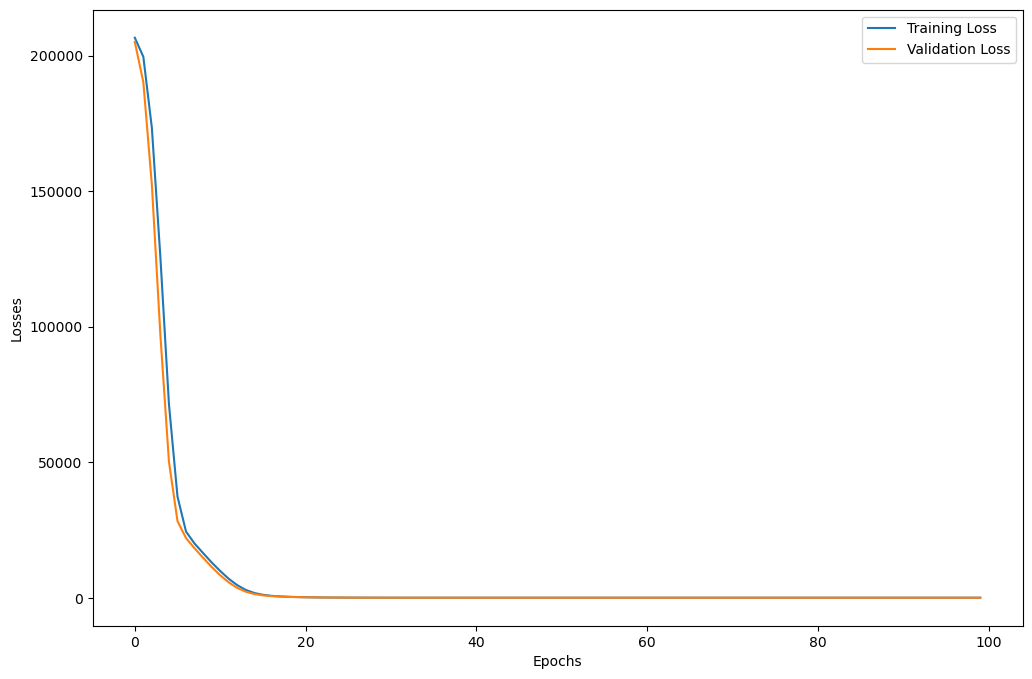

In [151]:
import matplotlib.pyplot as plt

loss_df = pd.DataFrame(
    {
        "training_losses": training_losses,
        "validation_losses": val_losses
    }
)

plt.figure(figsize= (12,8))
plt.plot(loss_df["training_losses"], label = "Training Loss")
plt.plot(loss_df["validation_losses"], label = "Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Losses")

plt.legend()

In [152]:
# Load the best Model
model.load_state_dict(torch.load("best_model.pt"))

<All keys matched successfully>

In [153]:
# Evaluate our model

model.eval()
with torch.no_grad():
    train_preds = model(X_train_tensor)
    test_preds = model(X_test_tensor)

    train_mse_loss = criterion(train_preds, y_train_tensor)
    test_mse_loss = criterion(test_preds, y_test_tensor)

print("Training MSE: ", train_mse_loss.item())
print("Testing MSE: ", test_mse_loss.item())
    

Training MSE:  20.573089599609375
Testing MSE:  18.979297637939453


In [154]:
from sklearn.metrics import r2_score

print("r^2 score = ", r2_score(y_test, test_preds))

r^2 score =  0.9336722563676034


In [155]:
predicted_df = pd.DataFrame(test_preds.numpy(), columns = ["Predicted Values"])
actual_df = pd.DataFrame(y_test.values, columns = ["Actual Values"])

pd.concat([predicted_df, actual_df], axis = 1)

,Predicted Values,Actual Values
0,435.239288,433.27
1,436.589233,438.16
2,461.402985,458.42
3,476.288452,480.82
4,435.236816,441.41
...,...,...
1909,451.284882,456.70
1910,431.438721,438.04
1911,467.646179,467.80
1912,430.799133,437.14
